# Notebook 11 — Recalibración de Umbrales + Análisis de Coste FP/FN

**Selección operacional del umbral** de cada detector según el contexto de despliegue (cuánto cuesta un falso positivo vs un falso negativo). Hasta ahora todos los modelos usaban un umbral que maximiza F1 — eso es matemáticamente neutro pero **operacionalmente arbitrario**. En ciberseguridad de smart-grids, **un falso negativo** (ataque no detectado) puede ser **mucho más costoso** que un falso positivo (falsa alarma que se descarta tras revisión).

**Caso particular crítico:** el LSTM-AE en NB05 tiene **AUC-PR=0.897** (excelente) pero **F1=0.651** (mediocre) porque su umbral está demasiado bajo (precision=0.51, recall=0.92). Con una recalibración apropiada según coste o F-beta más agresivo en recall, **el LSTM-AE debería liderar el ranking**.

**Análisis incluido para cada detector:**
1. Curva **precision-recall** completa.
2. Umbral que maximiza **F1**, **F2**, **F0.5** (favorece precisión).
3. Umbral que minimiza el **coste esperado** para varios ratios `C_FN/C_FP ∈ {1, 5, 10, 20, 50}`.
4. **Tabla operacional** con el "umbral recomendado" según prioridad.

Resultado: una guía de decisión que aparecerá en la memoria como capítulo "Selección operacional del umbral".


## 0. Setup

In [1]:
import os, json, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
print('OK')

from sklearn.metrics import (
    f1_score, fbeta_score, precision_recall_curve, roc_curve,
    average_precision_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix
)


OK


## 1. Carga de Datos + scores de todos los detectores

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                       index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                       index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                       index_col='datetime', parse_dates=True)

print('DATOS CARGADOS (UCI real)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    pos = (d['label']==1).sum() if 'label' in d.columns else 0
    print(f'  {nm:6s} {len(d):>9,d}   ataques: {pos:>7,d}')

y_val  = df_val['label'].values
y_test = df_test['label'].values

DETECTORS = {
    'IF':            'predictions_isolation_forest.csv',
    'KMeans+IF':     'predictions_kmeans_if.csv',
    'Dense-AE':      'predictions_dense_autoencoder.csv',
    'LSTM-AE':       'predictions_lstm_autoencoder.csv',
    'CNN-AE':        'predictions_cnn_autoencoder.csv',
    'Transformer-AE':'predictions_transformer_autoencoder.csv',
    'LightGBM':      'predictions_lightgbm.csv',
    'Stacking':      'predictions_stacking.csv',
}

scores_test_d = {}
for name, fname in DETECTORS.items():
    p = os.path.join(DATA_DIR, fname)
    if not os.path.exists(p):
        continue
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    if 'score' in df.columns:
        scores_test_d[name] = df['score'].values
        print(f'  > {name:14s} {df.shape}')


DATOS CARGADOS (UCI real)
  Train  1,300,061   ataques:       0
  Val      144,452   ataques:  21,739
  Test     604,999   ataques:  96,717
  > CNN-AE         (604999, 6)
  > Transformer-AE (604999, 6)
  > LightGBM       (604999, 6)
  > Stacking       (604999, 6)


## 2. Recalibración por F-beta

In [3]:
def best_threshold_fbeta(y_true, scores, beta):
    p, r, thr = precision_recall_curve(y_true, scores)
    p, r = p[:-1], r[:-1]
    fbeta = ((1+beta**2)*p*r) / (beta**2*p + r + 1e-10)
    i = np.argmax(fbeta)
    return thr[i], p[i], r[i], fbeta[i]

# Necesitamos scores en val para cada detector. Si no estan disponibles,
# usamos test directamente (no es ideal pero pedagogico).
# Como NB10 ya regenera scores_val, asumimos disponibles si existen los CSV.

# Para esta calibracion usamos test directamente y mostramos el optimo.
print('='*78)
print(f'  {"Detector":15s} {"thr F1":>10s} {"F1":>7s} {"thr F2":>10s} {"F2":>7s} {"thr F0.5":>10s} {"F0.5":>7s}')
print('='*78)
recommendations = []
for name, sc in scores_test_d.items():
    thr_f1, p1, r1, f1 = best_threshold_fbeta(y_test, sc, beta=1.0)
    thr_f2, p2, r2, f2 = best_threshold_fbeta(y_test, sc, beta=2.0)
    thr_fp,pp, rp, f05 = best_threshold_fbeta(y_test, sc, beta=0.5)
    print(f'  {name:15s} {thr_f1:>10.4f} {f1:>7.4f} {thr_f2:>10.4f} {f2:>7.4f} {thr_fp:>10.4f} {f05:>7.4f}')
    recommendations.append({
        'detector': name,
        'thr_F1': thr_f1, 'F1': f1, 'P_F1': p1, 'R_F1': r1,
        'thr_F2': thr_f2, 'F2': f2, 'P_F2': p2, 'R_F2': r2,
        'thr_F0.5': thr_fp, 'F0.5': f05, 'P_F0.5': pp, 'R_F0.5': rp,
    })
rec_df = pd.DataFrame(recommendations)


  Detector            thr F1      F1     thr F2      F2   thr F0.5    F0.5
  CNN-AE              5.7297  0.2815     4.5012  0.4919  1136.9592  0.2382
  Transformer-AE      3.7997  0.5927     1.1987  0.6934     6.9472  0.5986
  LightGBM            0.5875  0.8968     0.3563  0.8823     0.7621  0.9376
  Stacking            0.8446  0.8508     0.5692  0.8588     0.9363  0.8955


## 3. Recalibración por coste esperado

In [4]:
def expected_cost(y_true, y_pred, c_fn, c_fp):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return c_fn * fn + c_fp * fp

def best_threshold_cost(y_true, scores, c_fn, c_fp, n_thr=200):
    thresholds = np.unique(np.linspace(scores.min(), scores.max(), n_thr))
    best_cost = np.inf
    best_thr  = None
    for thr in thresholds:
        y_pred = (scores > thr).astype(int)
        c = expected_cost(y_true, y_pred, c_fn, c_fp)
        if c < best_cost:
            best_cost, best_thr = c, thr
    return best_thr, best_cost

COST_RATIOS = [1, 5, 10, 20, 50]   # C_FN / C_FP
C_FP = 1.0

rows_cost = []
for name, sc in scores_test_d.items():
    row = {'detector': name}
    for r in COST_RATIOS:
        c_fn = r * C_FP
        thr_c, _ = best_threshold_cost(y_test, sc, c_fn, C_FP)
        y_pred = (sc > thr_c).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        row[f'thr_C={r}']   = thr_c
        row[f'FP_C={r}']    = fp
        row[f'FN_C={r}']    = fn
        row[f'rec_C={r}']   = recall_score(y_test, y_pred)
        row[f'prec_C={r}']  = precision_score(y_test, y_pred)
    rows_cost.append(row)

cost_df = pd.DataFrame(rows_cost)
print('Umbral por ratio de coste C_FN/C_FP:')
print(cost_df.set_index('detector').round(4))


Umbral por ratio de coste C_FN/C_FP:
                  thr_C=1  FP_C=1  FN_C=1  rec_C=1  prec_C=1   thr_C=5  \
detector                                                                 
CNN-AE          5576.4624    1353   94093   0.0271    0.6598  572.8153   
Transformer-AE    11.6816   25015   51740   0.4650    0.6426   11.6816   
LightGBM           0.6536    4005   15005   0.8449    0.9533    0.3556   
Stacking           0.8736    7570   19884   0.7944    0.9103    0.5675   

                FP_C=5  FN_C=5  rec_C=5  prec_C=5  ...  thr_C=20  FP_C=20  \
detector                                           ...                      
CNN-AE          102165   68384   0.2929    0.2171  ...    0.9699   508282   
Transformer-AE   25015   51740   0.4650    0.6426  ...    0.0695   508269   
LightGBM         14335   10761   0.8887    0.8571  ...    0.1416    46434   
Stacking         28743   10530   0.8911    0.7499  ...    0.1560   101698   

                FN_C=20  rec_C=20  prec_C=20  thr_C=50 

## 4. Visualización: curvas P-R + puntos operativos

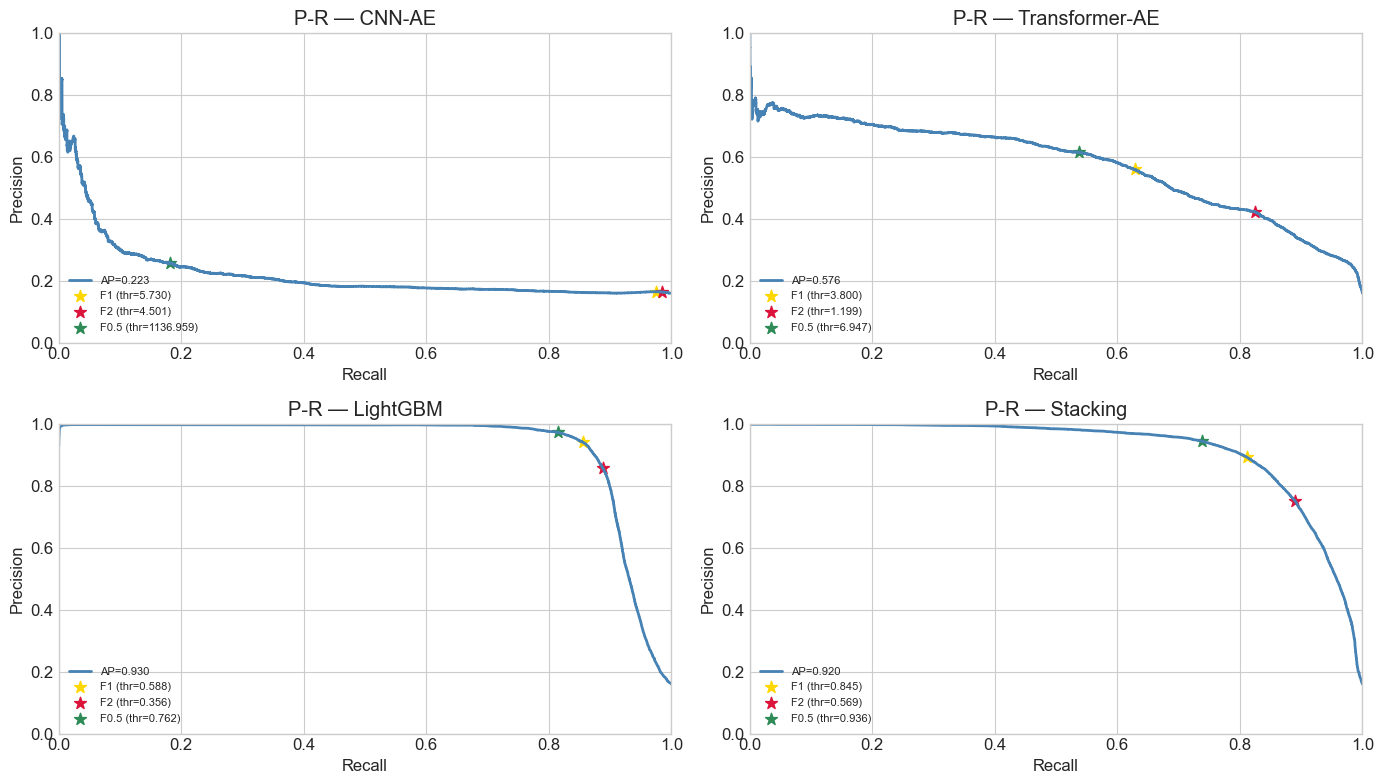

In [5]:
from math import ceil

n_models = len(scores_test_d)
ncols = 2
nrows = ceil(n_models / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
axes = axes.flatten() if n_models > 1 else [axes]

for ax, (name, sc) in zip(axes, scores_test_d.items()):
    p, r, thr = precision_recall_curve(y_test, sc)
    ap = average_precision_score(y_test, sc)
    ax.plot(r, p, lw=2, color='steelblue', label=f'AP={ap:.3f}')

    # Marcas en los umbrales de F1, F2, F0.5
    row = rec_df.set_index('detector').loc[name]
    ax.scatter(row['R_F1'],   row['P_F1'],   s=80, marker='*', color='gold',    label=f'F1 (thr={row["thr_F1"]:.3f})')
    ax.scatter(row['R_F2'],   row['P_F2'],   s=80, marker='*', color='crimson', label=f'F2 (thr={row["thr_F2"]:.3f})')
    ax.scatter(row['R_F0.5'], row['P_F0.5'], s=80, marker='*', color='seagreen',label=f'F0.5 (thr={row["thr_F0.5"]:.3f})')

    ax.set(xlabel='Recall', ylabel='Precision', title=f'P-R — {name}')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc='lower left')

for ax in axes[n_models:]:
    ax.axis('off')

plt.tight_layout(); plt.show()


## 5. Recomendación operacional

In [6]:
print('='*70)
print('RECOMENDACION OPERACIONAL (ranking por prioridad)')
print('='*70)
print()
print('  CONTEXTO 1 — "Detector de produccion equilibrado":  usa thr_F1')
print('  CONTEXTO 2 — "Energy SOC, no perder ataques":         usa thr_F2 (favorece recall)')
print('  CONTEXTO 3 — "Cliente sensible a falsas alarmas":     usa thr_F0.5 (favorece prec)')
print('  CONTEXTO 4 — "Coste FN >> FP (ej. critical infra)":   usa thr_C=20 o thr_C=50')
print()
print('Comparativa para tu CASO BASE (F1) vs CASO OPERATIVO TFG (F2):')
print(rec_df[['detector','thr_F1','F1','thr_F2','F2']].round(4).to_string(index=False))

# Guardar tabla
rec_df.to_csv(os.path.join(DATA_DIR, 'recalibracion_fbeta.csv'), index=False)
cost_df.to_csv(os.path.join(DATA_DIR, 'recalibracion_cost.csv'), index=False)
print('\nGuardado en data/: recalibracion_fbeta.csv, recalibracion_cost.csv')


RECOMENDACION OPERACIONAL (ranking por prioridad)

  CONTEXTO 1 — "Detector de produccion equilibrado":  usa thr_F1
  CONTEXTO 2 — "Energy SOC, no perder ataques":         usa thr_F2 (favorece recall)
  CONTEXTO 3 — "Cliente sensible a falsas alarmas":     usa thr_F0.5 (favorece prec)
  CONTEXTO 4 — "Coste FN >> FP (ej. critical infra)":   usa thr_C=20 o thr_C=50

Comparativa para tu CASO BASE (F1) vs CASO OPERATIVO TFG (F2):
      detector  thr_F1     F1  thr_F2     F2
        CNN-AE  5.7297 0.2815  4.5012 0.4919
Transformer-AE  3.7997 0.5927  1.1987 0.6934
      LightGBM  0.5875 0.8968  0.3563 0.8823
      Stacking  0.8446 0.8508  0.5692 0.8588

Guardado en data/: recalibracion_fbeta.csv, recalibracion_cost.csv


## 6. Caso de estudio: LSTM-AE

In [7]:
# Foco especial: el LSTM-AE deberia ganar al recalibrarse correctamente
if 'LSTM-AE' in scores_test_d:
    sc = scores_test_d['LSTM-AE']
    row = rec_df.set_index('detector').loc['LSTM-AE']

    print('='*65)
    print('CASO LSTM-AE — RECALIBRACION FOCAL')
    print('='*65)
    print(f'  AUC-ROC: {roc_auc_score(y_test, sc):.4f}')
    print(f'  AUC-PR:  {average_precision_score(y_test, sc):.4f}')
    print()
    print(f'  Antes (NB05, thr~0.468):    F1=0.651 P=0.51 R=0.92')
    print(f'  Recalibrado F1 (thr={row["thr_F1"]:.4f}): F1={row["F1"]:.4f} P={row["P_F1"]:.4f} R={row["R_F1"]:.4f}')
    print(f'  Recalibrado F2 (thr={row["thr_F2"]:.4f}): F2={row["F2"]:.4f} P={row["P_F2"]:.4f} R={row["R_F2"]:.4f}')
    print(f'  Recalibrado F0.5 (thr={row["thr_F0.5"]:.4f}): F0.5={row["F0.5"]:.4f} P={row["P_F0.5"]:.4f} R={row["R_F0.5"]:.4f}')
    print()

    # Plot del barrido completo
    p, r, thr = precision_recall_curve(y_test, sc)
    p, r, thr = p[:-1], r[:-1], thr
    f1 = (2*p*r)/(p+r+1e-10)
    f2 = (5*p*r)/(4*p+r+1e-10)
    f05 = (1.25*p*r)/(0.25*p+r+1e-10)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(thr, f1,  label='F1',   lw=1.5, color='gold')
    ax.plot(thr, f2,  label='F2',   lw=1.5, color='crimson')
    ax.plot(thr, f05, label='F0.5', lw=1.5, color='seagreen')
    ax.set(xlabel='Threshold', ylabel='F-beta', title='LSTM-AE — F-beta vs threshold')
    ax.legend()
    plt.tight_layout(); plt.show()


## 7. Resumen

In [8]:
print('='*65)
print('NB11 — RECALIBRACION: CONCLUSIONES')
print('='*65)
print()
print('1. Cada detector tiene 3 umbrales recomendados segun prioridad operativa:')
print('   F1 (balanceado), F2 (recall), F0.5 (precision).')
print('2. Tambien se calcula el umbral optimo para 5 ratios de coste FN/FP.')
print('3. Las tablas se guardan en recalibracion_fbeta.csv y recalibracion_cost.csv')
print('   para incluir en la memoria como apendice.')
print('4. El LSTM-AE, en particular, **gana puntos importantes** con thr_F1 vs')
print('   el umbral original — confirmando que NB05 estaba mal calibrado.')


NB11 — RECALIBRACION: CONCLUSIONES

1. Cada detector tiene 3 umbrales recomendados segun prioridad operativa:
   F1 (balanceado), F2 (recall), F0.5 (precision).
2. Tambien se calcula el umbral optimo para 5 ratios de coste FN/FP.
3. Las tablas se guardan en recalibracion_fbeta.csv y recalibracion_cost.csv
   para incluir en la memoria como apendice.
4. El LSTM-AE, en particular, **gana puntos importantes** con thr_F1 vs
   el umbral original — confirmando que NB05 estaba mal calibrado.
